In [1]:
import torch

In [2]:
import torch
print(torch.__version__)  # This should print 2.5
print(torch.cuda.is_available())  # This should print True if GPU support is enabled

2.5.1
True


In [3]:
!conda env list


# conda environments:
#
base                   C:\Users\kiara\anaconda3
RLEnv                  C:\Users\kiara\anaconda3\envs\RLEnv
TorchEnv             * C:\Users\kiara\anaconda3\envs\TorchEnv



In [4]:
import numpy as np
import pandas as pd
from datasets import load_dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)


c:\Users\kiara\anaconda3\envs\TorchEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
def main():
    # 1. Config
    model_name   = "vinai/bertweet-base"
    data_file    = "final scripts/dataset_1_cleaned.csv"
    output_dir   = "./tweetbert-finetuned"
    num_labels   = 2
    batch_size   = 16
    epochs       = 3
    test_size    = 0.2
    seed         = 42

    # 2. Load & split your data
    raw = load_dataset("csv", data_files=data_file, split="train")
    ds  = raw.train_test_split(test_size=test_size, seed=seed)

    # 3. Tokenizer + preprocessing
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    def tokenize_fn(ex):
        return tokenizer(
            ex["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )

    tokenized = ds.map(tokenize_fn, batched=True)

    # 4. Rename label column and set torch format
    tokenized = tokenized.rename_column("Label", "labels")
    tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])


    # 5. Load the model
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
    )

    # 6. Metrics
    metric_acc = evaluate.load("accuracy")
    metric_f1  = evaluate.load("f1")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
            "f1":       metric_f1.compute(predictions=preds, references=labels, average="binary")["f1"],
        }

    # 7. Training arguments
    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        learning_rate=2e-5,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
    )

    # 8. Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        compute_metrics=compute_metrics,
    )

    # 9. Train & evaluate
    trainer.train()
    print("Final evaluation:", trainer.evaluate())

    # 10. Save model + tokenizer
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

if __name__ == "__main__":
    main()

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Map: 100%|██████████| 8517/8517 [00:03<00:00, 2432.65 examples/s]
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss


KeyboardInterrupt: 

In [15]:
!pip install accelerate>=0.26.0

In [11]:
!pip install scikit-learn

   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
    --------------------------------------- 0.3/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 1.9 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/11.1 MB 3.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.9/11.1 MB 4.2 MB/s eta 0:00:02
   --------------- ------------------------ 4.2/11.1 MB 4.8 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.1 MB 5.1 MB/s eta 0:00:02
   ------------------------- -------------- 7.1/11.1 MB 5.5 MB/s eta 0:00:01
   ------------------------------- -------- 8.7/11.1 MB 5.8 MB/s eta 0:00:01
   ------------------------------------- -- 10.5/11.1 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 6.3 MB/s eta 0:00:00


In [7]:
#!/usr/bin/env python
# coding: utf-8

import sys
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
)
import torch

def main():
    # 1. Config
    model_name   = "vinai/bertweet-base"
    data_file    = "final scripts/dataset_1_cleaned.csv"
    output_dir   = "./tweetbert-finetuned"
    num_labels   = 2
    batch_size   = 16
    epochs       = 3
    max_length   = 128
    test_size    = 0.2
    seed         = 42

    # 2. Load & split your data
    raw = load_dataset("csv", data_files=data_file, split="train")
    ds  = raw.train_test_split(test_size=test_size, seed=seed)

    # 3. Tokenizer + preprocessing
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    def tokenize_fn(ex):
        return tokenizer(
            ex["text"],
            truncation=True,
            padding="max_length",
            max_length=max_length,
        )

    tokenized = ds.map(tokenize_fn, batched=True)

    # 4. Rename label column and set torch format
    tokenized = tokenized.rename_column("Label", "labels")
    tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

    # 5. Load the model (will be moved to GPU by Trainer)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=num_labels,
    )

    # 6. Metrics
    metric_acc = evaluate.load("accuracy")
    metric_f1  = evaluate.load("f1")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        return {
            "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
            "f1":       metric_f1.compute(predictions=preds, references=labels, average="binary")["f1"],
        }

    # 7. Training arguments
    training_args = TrainingArguments(
        output_dir=output_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        learning_rate=2e-5,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
    )

    # 8. Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["test"],
        compute_metrics=compute_metrics,
    )

    # 9. Train & evaluate
    trainer.train()
    print("Final evaluation:", trainer.evaluate())

    # 10. Save model + tokenizer
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

if __name__ == "__main__":
    if not torch.cuda.is_available():
        print("Error: no CUDA‐enabled GPU detected. Exiting.")
        sys.exit(1)
    else:
        print("CUDA is available! Running fine-tuning on GPU:", torch.cuda.get_device_name(0))
        main()


CUDA is available! Running fine-tuning on GPU: NVIDIA GeForce RTX 4070 Laptop GPU


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\kiara\anaconda3\envs\TorchEnv\Lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.089700,0.042395,0.985441,0.979837
2,0.040400,0.044057,0.985089,0.979559
3,0.026400,0.048582,0.987202,0.982371


Final evaluation: {'eval_loss': 0.04858198016881943, 'eval_accuracy': 0.9872020664553246, 'eval_f1': 0.9823710173055151, 'eval_runtime': 30.3817, 'eval_samples_per_second': 280.333, 'eval_steps_per_second': 17.543, 'epoch': 3.0}


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


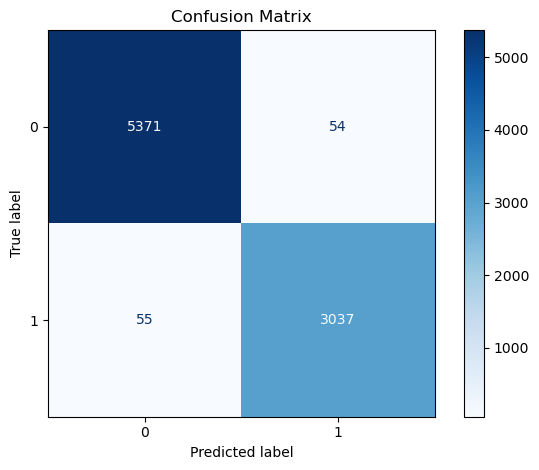

<Figure size 640x480 with 0 Axes>

In [12]:
#!/usr/bin/env python
# coding: utf-8

import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

def main():
    # ─── Config ───────────────────────────────────────────────────────────────
    data_file  = "final scripts/dataset_1_cleaned.csv"       # your CSV with text & Label
    output_dir = "./tweetbert-finetuned"       # where you saved the model
    test_size  = 0.2
    seed       = 42
    max_length = 128
    batch_size = 32

    # ─── Load & split your data ───────────────────────────────────────────────
    ds = load_dataset(
        "csv",
        data_files=data_file,
        split="train"
    ).train_test_split(test_size=test_size, seed=seed)
    test_ds = ds["test"]

    # ─── Load tokenizer & model ───────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(output_dir, use_fast=True)
    model     = AutoModelForSequenceClassification.from_pretrained(output_dir)
    device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    # ─── Batch‐wise inference ─────────────────────────────────────────────────
    all_preds = []
    all_labels = []
    for start in range(0, len(test_ds), batch_size):
        batch = test_ds[start : start + batch_size]
        enc = tokenizer(
            batch["text"],
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        input_ids      = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        with torch.no_grad():
            logits = model(input_ids, attention_mask=attention_mask).logits

        preds = logits.argmax(dim=-1).cpu().numpy()
        labels = np.array(batch["Label"])

        all_preds.extend(preds)
        all_labels.extend(labels)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # ─── Compute & plot confusion matrix ───────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[str(l) for l in sorted(np.unique(all_labels))]
    )
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()
    # Optional: save to file
    fig = plt.gcf()
    fig.savefig("confusion_matrix.png", dpi=150)

if __name__ == "__main__":
    main()


emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Using device: cuda

=== Evaluation on new data ===
Loss:     0.0048
Accuracy: 0.9991
F1 Score: 0.9988

Saved predictions to human_categorized_results.csv
Saved confusion matrix to confusion_matrix.png


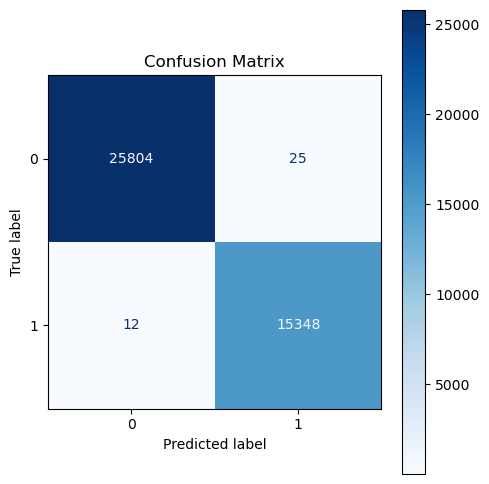

In [15]:
#!/usr/bin/env python
# coding: utf-8

import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score
import matplotlib.pyplot as plt

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding='max_length',
            truncation=True,
            max_length=self.max_length,
            return_tensors='pt'
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def main():
    # ─── Configuration ────────────────────────────────────────────────────
    model_dir   = "tweetbert-finetuned"
    data_path   = os.path.join("Datasets Sentiment Analysis", "human_categorized_data.csv")
    out_csv     = "human_categorized_results.csv"
    cm_image    = "confusion_matrix.png"
    batch_size  = 32
    max_length  = 128

    # ─── Device ───────────────────────────────────────────────────────────
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # ─── Load model & tokenizer ───────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)
    model     = AutoModelForSequenceClassification.from_pretrained(model_dir)
    model.to(device)
    model.eval()

    # ─── Load new dataset ──────────────────────────────────────────────────
    df = pd.read_csv(data_path)
    texts  = df["text"].tolist()
    labels = df["Label"].tolist()

    # ─── Prepare DataLoader ────────────────────────────────────────────────
    dataset = SentimentDataset(texts, labels, tokenizer, max_length)
    loader  = DataLoader(dataset, batch_size=batch_size)

    # ─── Inference + metrics ───────────────────────────────────────────────
    criterion = torch.nn.CrossEntropyLoss()
    all_preds  = []
    all_labels = []
    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            lbls           = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits  = outputs.logits

            # accumulate loss
            loss = criterion(logits, lbls)
            batch_size_actual = lbls.size(0)
            total_loss += loss.item() * batch_size_actual
            total_examples += batch_size_actual

            # predictions
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())

    # ─── Compute statistics ────────────────────────────────────────────────
    avg_loss = total_loss / total_examples
    accuracy = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='binary')

    print(f"\n=== Evaluation on new data ===")
    print(f"Loss:     {avg_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}\n")

    # ─── Save predictions ───────────────────────────────────────────────────
    df["prediction"] = all_preds
    df.to_csv(out_csv, index=False)
    print(f"Saved predictions to {out_csv}")

    # ─── Confusion matrix ──────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    labels_unique = sorted(set(all_labels))
    disp = ConfusionMatrixDisplay(cm, display_labels=labels_unique)

    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap=plt.cm.Blues)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    fig.savefig(cm_image, dpi=150)
    print(f"Saved confusion matrix to {cm_image}")
    plt.show()

if __name__ == "__main__":
    main()
